# Project FORESIGHT — Exploratory Data Analysis

## AI-Powered Demand & Inventory Intelligence Platform

### Week 2 — Data Analytics & Exploratory Analysis

**Role:** Data Analyst

### Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the cleaned and integrated FORESIGHT dataset.

The analysis focuses on understanding:

- Sales and demand patterns
- SKU-level performance
- Category-level performance
- Seasonal demand patterns
- Promotional effects
- Inventory and potential dead-stock indicators
- Relationships between important business variables

The findings from this analysis will support demand forecasting, inventory-risk analysis, and downstream machine learning development.

### Data Source

The analysis uses the processed dataset:

`data/processed/analysis_ready.csv`

The dataset was prepared from the Sales, SKU Master, Calendar, and Inventory datasets during Week 1 data-quality and cleaning activities.

In [52]:
import sys
print(sys.executable)

c:\Python313\python.exe


In [53]:
# Core data analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plotting style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [54]:
# Load the processed FORESIGHT dataset

file_path = "../data/processed/analysis_ready.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (20906, 26)


In [55]:
# Display the first 5 rows of the dataset

df.head()

,date,sku_id,units_sold,revenue,price,promo_flag,calculated_revenue,revenue_difference,revenue_consistency_flag,category,subcategory,launch_date,unit_cost,list_price,sku_quality_flag,week,month,season,is_holiday,promo_event,promo_flag_calendar,on_hand_units,on_order_units,lead_time_days,reorder_point,inventory_quality_flag
0,2025-01-01,SKU001,52.0,245974.56,4730.28,0,245974.56,0.000000e+00,OK,Furniture,Chair,2024-02-14,2362.73,4730.28,OK,1,1,Winter,0,NaN,0,284.0,125,6.0,255,OK
1,2025-01-02,SKU001,69.0,326389.32,4730.28,0,326389.32,0.000000e+00,OK,Furniture,Chair,2024-02-14,2362.73,4730.28,OK,1,1,Winter,0,NaN,0,215.0,128,6.0,255,OK
2,2025-01-03,SKU001,49.0,231783.72,4664.22,0,228546.78,3.236940e+03,REVENUE_MISMATCH,Furniture,Chair,2024-02-14,2362.73,4730.28,OK,1,1,Winter,0,NaN,0,166.0,186,6.0,255,OK
3,2025-01-04,SKU001,74.0,350040.72,7387.17,0,546650.58,-1.966099e+05,REVENUE_MISMATCH,Furniture,Chair,2024-02-14,2362.73,4730.28,OK,1,1,Winter,0,NaN,0,92.0,62,6.0,255,OK
4,2025-01-05,SKU001,43.0,203402.04,4730.28,0,203402.04,2.910383e-11,OK,Furniture,Chair,2024-02-14,2362.73,4730.28,OK,1,1,Winter,0,NaN,0,49.0,112,6.0,255,OK


In [56]:
# Check the dataset structure

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20906 entries, 0 to 20905
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      20906 non-null  str    
 1   sku_id                    20906 non-null  str    
 2   units_sold                20891 non-null  float64
 3   revenue                   20906 non-null  float64
 4   price                     20896 non-null  float64
 5   promo_flag                20906 non-null  int64  
 6   calculated_revenue        20881 non-null  float64
 7   revenue_difference        20881 non-null  float64
 8   revenue_consistency_flag  20906 non-null  str    
 9   category                  20906 non-null  str    
 10  subcategory               20906 non-null  str    
 11  launch_date               20906 non-null  str    
 12  unit_cost                 20360 non-null  float64
 13  list_price                20906 non-null  float64
 14  sku_quality_flag 

In [57]:
# Check missing values in each column

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

promo_event           17634
unit_cost               546
on_hand_units            40
calculated_revenue       25
revenue_difference       25
units_sold               15
price                    10
dtype: int64

In [58]:
# Generate descriptive statistics for numerical columns

df.describe()

,units_sold,revenue,price,promo_flag,calculated_revenue,revenue_difference,unit_cost,list_price,week,month,is_holiday,promo_flag_calendar,on_hand_units,on_order_units,lead_time_days,reorder_point
count,20891.000000,2.090600e+04,20896.000000,20906.000000,2.088100e+04,2.088100e+04,20360.000000,20906.000000,20906.000000,20906.000000,20906.000000,20906.000000,20866.000000,20906.000000,20906.000000,20906.000000
mean,60.829783,2.354490e+05,4070.395135,0.156510,2.399302e+05,-4.513103e+03,2492.511256,4071.884657,22.920980,5.678370,0.011002,0.156510,20.867536,91.305176,7.729982,340.341385
std,34.378615,2.000886e+05,2168.798149,0.363347,2.114470e+05,4.983826e+04,1259.409723,2166.808288,14.241605,3.289357,0.104313,0.363347,76.400982,79.939978,3.766675,260.133322
min,1.000000,7.387170e+03,637.850000,0.000000,7.387170e+03,-4.954907e+06,334.600000,637.850000,1.000000,1.000000,0.000000,0.000000,-25.000000,0.000000,2.000000,48.000000
25%,34.000000,8.912190e+04,1844.520000,0.000000,9.010113e+04,0.000000e+00,1366.470000,1844.520000,11.000000,3.000000,0.000000,0.000000,0.000000,28.000000,5.000000,129.000000
50%,59.000000,1.569157e+05,4088.420000,0.000000,1.609216e+05,0.000000e+00,2362.730000,4088.420000,21.000000,5.000000,0.000000,0.000000,0.000000,71.000000,7.000000,255.000000
75%,83.000000,3.273227e+05,5788.570000,0.000000,3.311196e+05,0.000000e+00,3577.630000,5788.570000,34.000000,8.000000,0.000000,0.000000,0.000000,142.000000,11.000000,460.000000
max,840.000000,1.484829e+06,8525.330000,1.000000,5.662751e+06,2.373609e+05,4847.300000,8525.330000,52.000000,12.000000,1.000000,1.000000,1436.000000,349.000000,14.000000,1231.000000


In [59]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [60]:
# Check the number of unique SKUs

unique_skus = df["sku_id"].nunique()

print("Number of unique SKUs:", unique_skus)

Number of unique SKUs: 40


In [61]:
# Check the date range of the dataset

print("Start Date:", df["date"].min())
print("End Date:", df["date"].max())

Start Date: 2025-01-01
End Date: 2026-06-30


In [62]:
# Display all column names

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. date
2. sku_id
3. units_sold
4. revenue
5. price
6. promo_flag
7. calculated_revenue
8. revenue_difference
9. revenue_consistency_flag
10. category
11. subcategory
12. launch_date
13. unit_cost
14. list_price
15. sku_quality_flag
16. week
17. month
18. season
19. is_holiday
20. promo_event
21. promo_flag_calendar
22. on_hand_units
23. on_order_units
24. lead_time_days
25. reorder_point
26. inventory_quality_flag


In [63]:
# Create a quick summary of the dataset

summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Unique SKUs",
        "Start Date",
        "End Date"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df["sku_id"].nunique(),
        df["date"].min(),
        df["date"].max()
    ]
})

summary

,Metric,Value
0,Total Rows,20906
1,Total Columns,26
2,Unique SKUs,40
3,Start Date,2025-01-01
4,End Date,2026-06-30


In [64]:
# Identify the main sales and demand columns

sales_columns = [
    column for column in df.columns
    if any(keyword in column.lower()
           for keyword in ["unit", "sales", "revenue", "price"])
]

print("Sales & demand related columns:")
for column in sales_columns:
    print("-", column)

Sales & demand related columns:
- units_sold
- revenue
- price
- calculated_revenue
- revenue_difference
- revenue_consistency_flag
- unit_cost
- list_price
- on_hand_units
- on_order_units


In [65]:
# Calculate key sales and revenue metrics

sales_summary = pd.DataFrame({
    "Metric": [
        "Total Units Sold",
        "Total Revenue",
        "Average Units Sold per Record",
        "Average Revenue per Record",
        "Average Selling Price"
    ],
    "Value": [
        df["units_sold"].sum(),
        df["revenue"].sum(),
        df["units_sold"].mean(),
        df["revenue"].mean(),
        df["price"].mean()
    ]
})

sales_summary

,Metric,Value
0,Total Units Sold,1.270795e+06
1,Total Revenue,4.922297e+09
2,Average Units Sold per Record,6.082978e+01
3,Average Revenue per Record,2.354490e+05
4,Average Selling Price,4.070395e+03


In [66]:
# Analyze revenue consistency

revenue_check = df["revenue_consistency_flag"].value_counts(dropna=False)

print("Revenue consistency status:")
print(revenue_check)

Revenue consistency status:
revenue_consistency_flag
OK                  17593
REVENUE_MISMATCH     3288
MISSING_INPUT          25
Name: count, dtype: int64


In [67]:
# Calculate revenue mismatch statistics

mismatch_count = (
    df["revenue_consistency_flag"]
    .astype(str)
    .str.contains("MISMATCH", case=False, na=False)
    .sum()
)

total_records = len(df)

mismatch_percentage = (mismatch_count / total_records) * 100

print("Total Records:", total_records)
print("Revenue Mismatches:", mismatch_count)
print(f"Mismatch Percentage: {mismatch_percentage:.2f}%")

Total Records: 20906
Revenue Mismatches: 3288
Mismatch Percentage: 15.73%


In [68]:
# Calculate revenue mismatch amount

df["revenue_difference"].describe()

count    2.088100e+04
mean    -4.513103e+03
std      4.983826e+04
min     -4.954907e+06
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.373609e+05
Name: revenue_difference, dtype: float64

In [69]:
# Count revenue consistency issues

mismatch_count = (
    df["revenue_consistency_flag"]
    .astype(str)
    .str.upper()
    .eq("REVENUE_MISMATCH")
    .sum()
)

total_records = len(df)

mismatch_percentage = (mismatch_count / total_records) * 100

print("Revenue mismatch records:", mismatch_count)
print("Total records:", total_records)
print(f"Mismatch percentage: {mismatch_percentage:.2f}%")

Revenue mismatch records: 3288
Total records: 20906
Mismatch percentage: 15.73%


In [70]:
# Analyze the magnitude of revenue differences

revenue_difference_summary = df["revenue_difference"].describe()

revenue_difference_summary

count    2.088100e+04
mean    -4.513103e+03
std      4.983826e+04
min     -4.954907e+06
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.373609e+05
Name: revenue_difference, dtype: float64

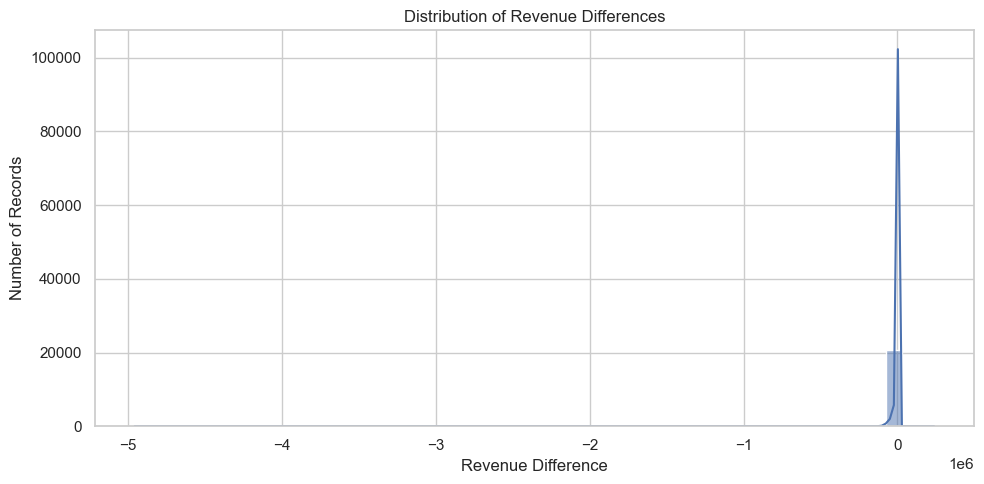

In [71]:
# Visualize the distribution of revenue differences

plt.figure(figsize=(10, 5))

sns.histplot(
    df["revenue_difference"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Revenue Differences")
plt.xlabel("Revenue Difference")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [72]:
# Calculate total daily demand

daily_demand = (
    df.groupby("date", as_index=False)["units_sold"]
      .sum()
      .sort_values("date")
)

daily_demand.head()

,date,units_sold
0,2025-01-01,1358.0
1,2025-01-02,1394.0
2,2025-01-03,1616.0
3,2025-01-04,1636.0
4,2025-01-05,1458.0


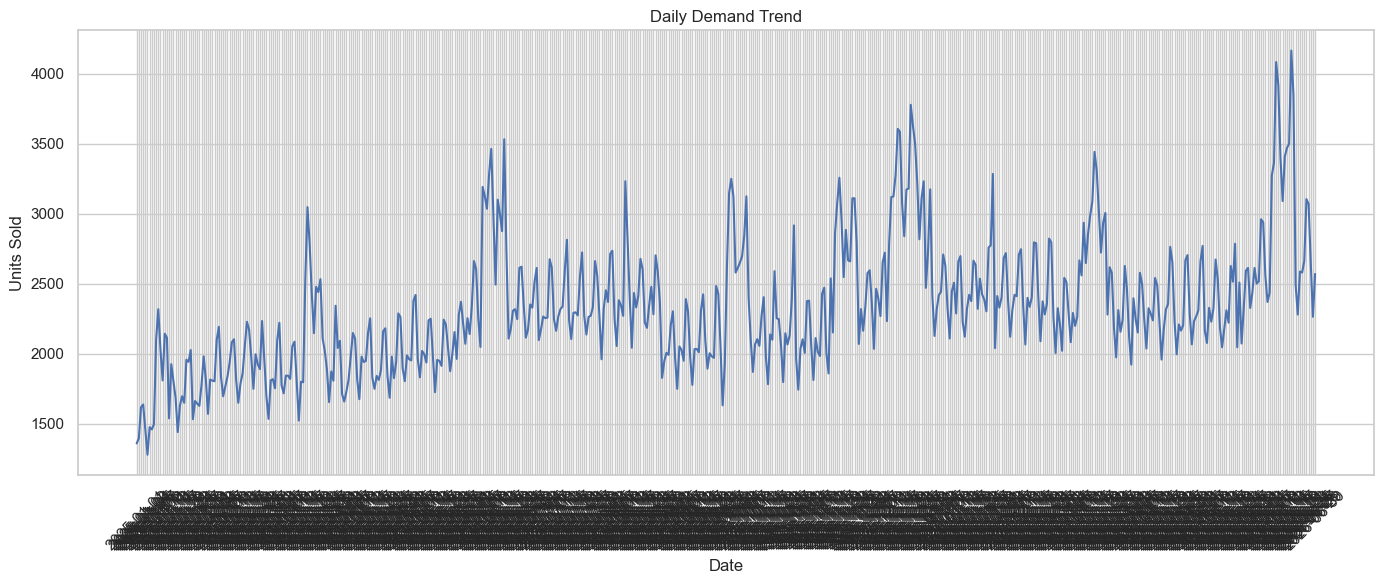

In [73]:
# Plot daily demand trend

plt.figure(figsize=(14, 6))

plt.plot(
    daily_demand["date"],
    daily_demand["units_sold"]
)

plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [74]:
# Aggregate demand by month

df["date"] = pd.to_datetime(df["date"])

monthly_demand = (
    df.groupby(df["date"].dt.to_period("M"))["units_sold"]
    .sum()
    .reset_index()
)

monthly_demand["date"] = monthly_demand["date"].dt.to_timestamp()

monthly_demand.head()

,date,units_sold
0,2025-01-01,53197.0
1,2025-02-01,53636.0
2,2025-03-01,62991.0
3,2025-04-01,57830.0
4,2025-05-01,63751.0


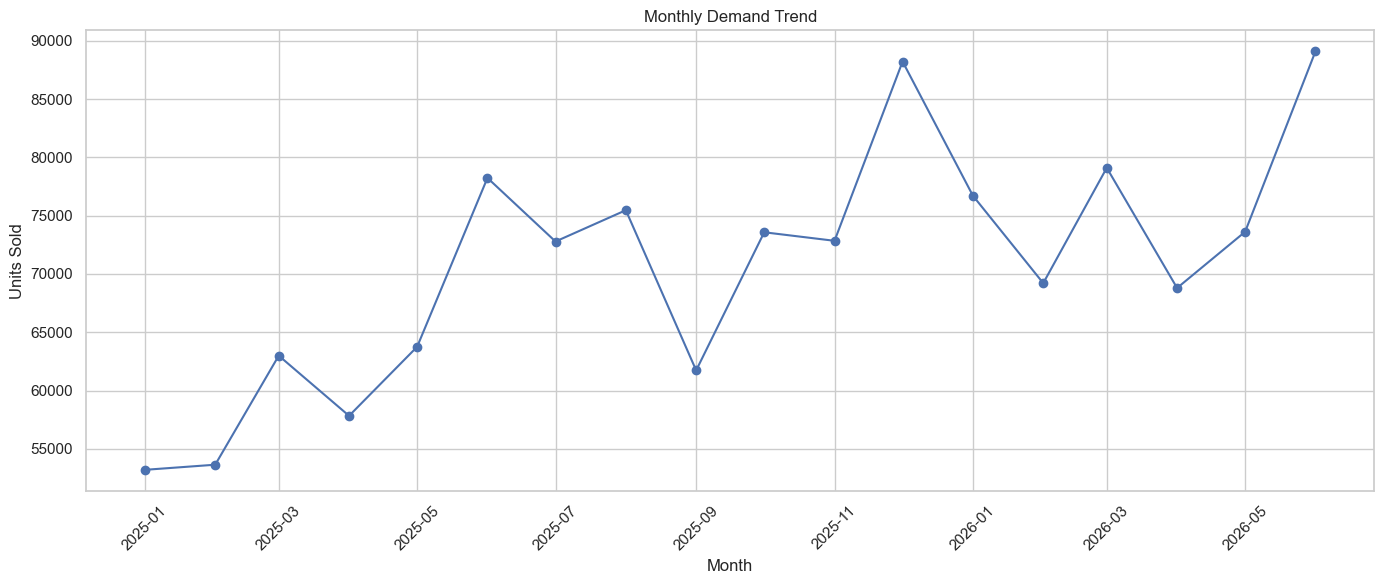

In [75]:
# Plot monthly demand trend

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_demand["date"],
    monthly_demand["units_sold"],
    marker="o"
)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Top 10 SKUs by total units sold:
sku_id
SKU008    58910.0
SKU011    58494.0
SKU023    56490.0
SKU026    56310.0
SKU020    53300.0
SKU016    52832.0
SKU005    49118.0
SKU007    48638.0
SKU018    45073.0
SKU014    44996.0
Name: units_sold, dtype: float64


C:\Users\sharkon\AppData\Local\Temp\ipykernel_20680\1894834915.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_skus.index, y=top_10_skus.values, palette="viridis")


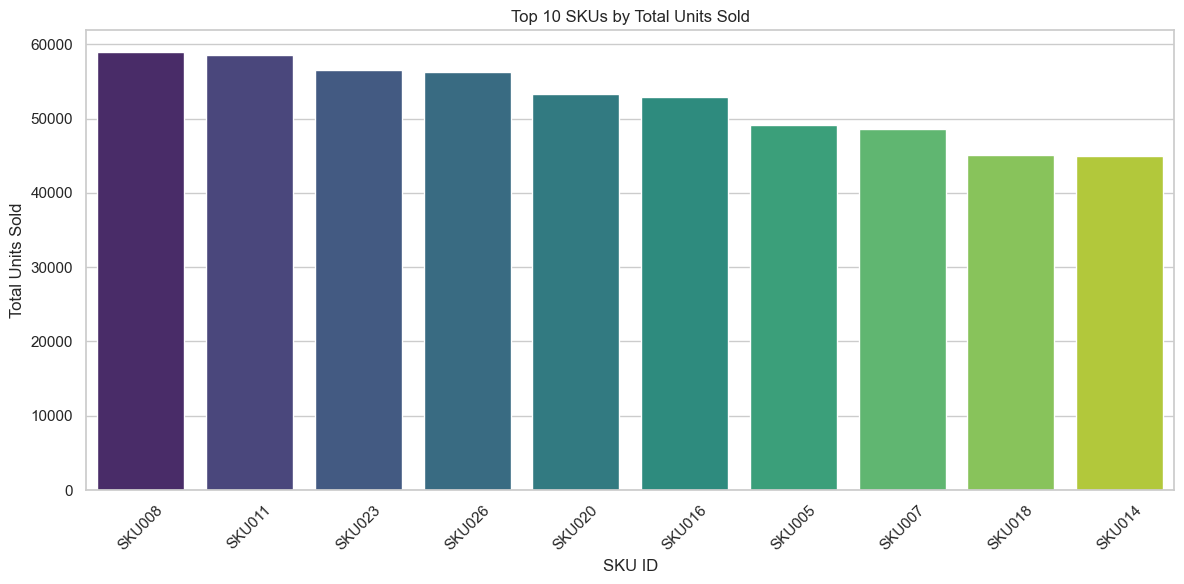

In [76]:
# Calculate total demand by SKU

sku_demand = (
    df.groupby("sku_id")["units_sold"]
    .sum()
    .sort_values(ascending=False)
)

top_10_skus = sku_demand.head(10)

print("Top 10 SKUs by total units sold:")
print(top_10_skus)

# Plot top 10 SKUs by total units sold
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_skus.index, y=top_10_skus.values, palette="viridis")
plt.title("Top 10 SKUs by Total Units Sold")
plt.xlabel("SKU ID")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [77]:
# Display Top 10 SKUs with their total units sold

top_10_sku_table = (
    df.groupby("sku_id")["units_sold"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
      .rename(columns={"units_sold": "total_units_sold"})
)

top_10_sku_table

,sku_id,total_units_sold
0,SKU008,58910.0
1,SKU011,58494.0
2,SKU023,56490.0
3,SKU026,56310.0
4,SKU020,53300.0
5,SKU016,52832.0
6,SKU005,49118.0
7,SKU007,48638.0
8,SKU018,45073.0
9,SKU014,44996.0


In [78]:
# Display Top 10 SKUs by total revenue

top_10_revenue_sku = (
    df.groupby("sku_id")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
      .rename(columns={"revenue": "total_revenue"})
)

top_10_revenue_sku

,sku_id,total_revenue
0,SKU008,4.194832e+08
1,SKU005,3.914684e+08
2,SKU026,3.696679e+08
3,SKU010,2.513206e+08
4,SKU020,2.449626e+08
5,SKU023,2.247857e+08
6,SKU035,2.162594e+08
7,SKU022,1.947767e+08
8,SKU017,1.883168e+08
9,SKU011,1.830162e+08


### Top 10 SKUs by Revenue

This analysis identifies the SKUs generating the highest total revenue during the available period.

Understanding the highest-revenue SKUs helps identify important products that may require priority attention in demand forecasting and inventory planning.

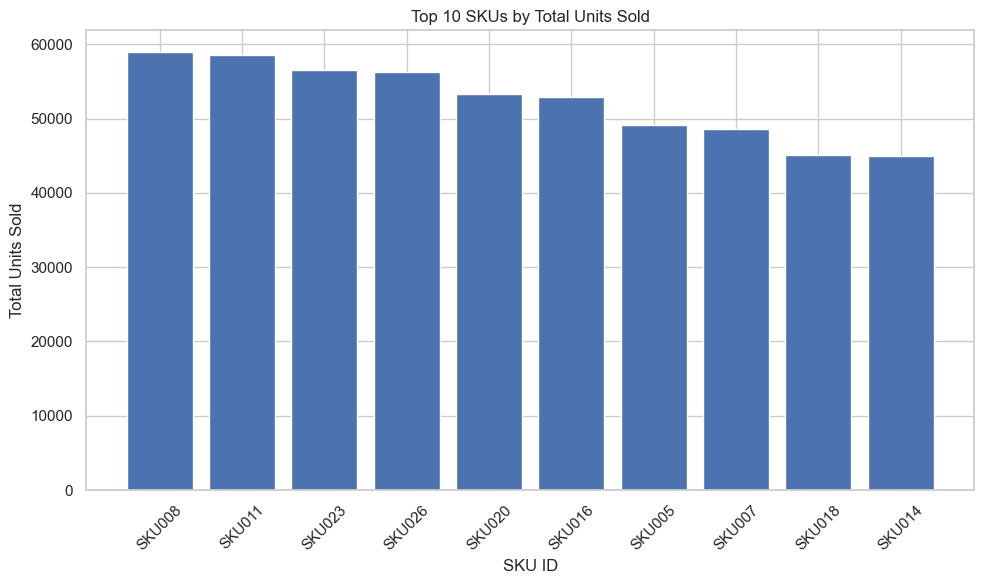

In [100]:
# Visualize Top 10 SKUs by total units sold

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_sku_table["sku_id"].astype(str),
    top_10_sku_table["total_units_sold"]
)

plt.title("Top 10 SKUs by Total Units Sold")
plt.xlabel("SKU ID")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Category-Level Sales Analysis

This section analyzes sales performance across different product categories.

The objective is to identify which categories generate the highest sales volume and revenue.

This analysis can help with:

- Category-level demand understanding
- Inventory allocation
- Product portfolio decisions
- Demand forecasting

In [101]:
# Calculate category-level sales performance

category_sales = (
    df.groupby("category")
      .agg(
          total_units_sold=("units_sold", "sum"),
          total_revenue=("revenue", "sum"),
          average_price=("price", "mean")
      )
      .sort_values("total_units_sold", ascending=False)
      .reset_index()
)

category_sales

,category,total_units_sold,total_revenue,average_price
0,Office,349266.0,1.110299e+09,2887.471507
1,Home Decor,345294.0,1.465047e+09,4536.816822
2,Small Appliances,337152.0,1.178681e+09,3868.520041
3,Furniture,239083.0,1.168270e+09,5059.190709


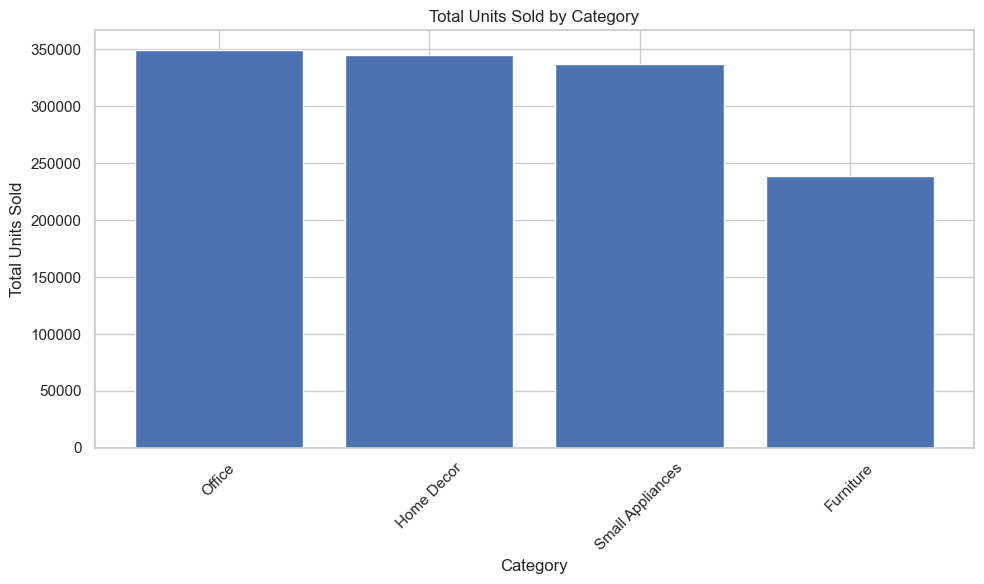

In [102]:
# Visualize total units sold by category

plt.figure(figsize=(10, 6))

plt.bar(
    category_sales["category"].astype(str),
    category_sales["total_units_sold"]
)

plt.title("Total Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Monthly Sales Trend

This section analyzes how sales change over time.

Understanding monthly sales patterns helps identify:

- Increasing or decreasing demand
- Seasonal demand patterns
- High-sales and low-sales periods
- Trends that can support future demand forecasting

In [103]:
# Calculate monthly sales performance

monthly_sales = (
    df.groupby("month")
      .agg(
          total_units_sold=("units_sold", "sum"),
          total_revenue=("revenue", "sum")
      )
      .reset_index()
      .sort_values("month")
)

monthly_sales

,month,total_units_sold,total_revenue
0,1,129908.0,5.140201e+08
1,2,122845.0,4.802305e+08
2,3,142094.0,5.408157e+08
3,4,126625.0,4.951799e+08
4,5,137371.0,5.417427e+08
5,6,167335.0,6.363319e+08
6,7,72783.0,2.866370e+08
7,8,75468.0,2.963754e+08
8,9,61727.0,2.424466e+08
9,10,73575.0,2.817558e+08


## Promotion Analysis

This section evaluates the relationship between promotional activity and product demand.

The objective is to understand whether products sold during promotional periods generate higher sales volumes.

This can help support:

- Promotion effectiveness analysis
- Demand planning
- Inventory preparation
- Future promotional strategies

In [107]:
# Check columns related to promotion

promotion_columns = [
    col for col in df.columns
    if "promo" in col.lower()
]

print("Promotion-related columns:")
print(promotion_columns)


Promotion-related columns:
['promo_flag', 'promo_event', 'promo_flag_calendar']


In [111]:
# Compare sales performance during promotional and non-promotional periods

promotion_analysis = (
    df.groupby("promo_flag")
      .agg(
          total_units_sold=("units_sold", "sum"),
          total_revenue=("revenue", "sum"),
          average_units_sold=("units_sold", "mean"),
          average_revenue=("revenue", "mean")
      )
      .reset_index()
)

promotion_analysis

,promo_flag,total_units_sold,total_revenue,average_units_sold,average_revenue
0,0,1015739.0,3.993093e+09,57.601168,226442.864392
1,1,255056.0,9.292036e+08,78.310101,283986.434490


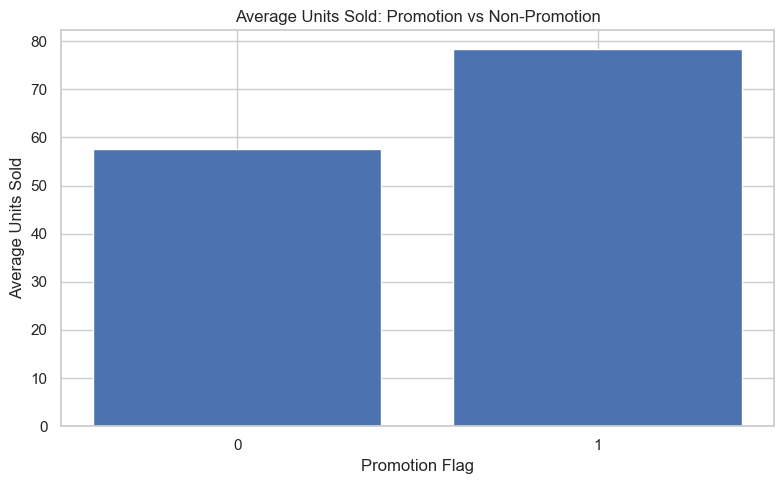

In [112]:
# Visualize average units sold by promotion status

plt.figure(figsize=(8, 5))

plt.bar(
    promotion_analysis["promo_flag"].astype(str),
    promotion_analysis["average_units_sold"]
)

plt.title("Average Units Sold: Promotion vs Non-Promotion")
plt.xlabel("Promotion Flag")
plt.ylabel("Average Units Sold")
plt.tight_layout()
plt.show()

## Inventory & Stock Analysis

This section analyzes inventory levels across SKUs.

The objective is to identify products with low inventory, high inventory, and potential dead-stock risk.

These insights can help improve inventory planning and support future demand forecasting.

In [114]:
# Find inventory and stock-related columns

inventory_columns = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in ["inventory", "stock"])
]

print("Inventory/Stock-related columns:")
print(inventory_columns)

Inventory/Stock-related columns:
['inventory_quality_flag']


## Inventory Quality Analysis

The dataset does not contain a direct inventory quantity measure.

Instead, `inventory_quality_flag` is used to identify the quality or status of inventory-related records.

This analysis examines the distribution of inventory-quality flags to identify potential data-quality or inventory-related issues.

In [115]:
# Analyze inventory quality flags

inventory_quality = (
    df["inventory_quality_flag"]
      .value_counts(dropna=False)
      .reset_index()
)

inventory_quality.columns = ["inventory_quality_flag", "record_count"]

inventory_quality

,inventory_quality_flag,record_count
0,OK,20865
1,MISSING_ON_HAND,40
2,NEGATIVE_ON_HAND,1


## Potential Dead-Stock Analysis

Dead stock refers to products that have very low or no sales activity over the analyzed period.

Identifying low-demand SKUs can help businesses:

- Reduce excess inventory risk
- Improve product-level inventory decisions
- Identify products requiring promotional attention
- Improve future demand forecasting

In [116]:
# Calculate total units sold for each SKU

sku_demand = (
    df.groupby("sku_id")["units_sold"]
      .sum()
      .reset_index()
      .rename(columns={"units_sold": "total_units_sold"})
)

sku_demand.head(10)

,sku_id,total_units_sold
0,SKU001,32192.0
1,SKU002,14348.0
2,SKU003,6557.0
3,SKU004,19093.0
4,SKU005,49118.0
5,SKU006,7709.0
6,SKU007,48638.0
7,SKU008,58910.0
8,SKU009,10212.0
9,SKU010,30241.0


## Correlation Analysis

Correlation analysis is used to understand the relationships between important numerical variables in the dataset.

A positive correlation indicates that two variables tend to increase together, while a negative correlation indicates an inverse relationship.

This analysis can help identify variables that may be useful for future demand forecasting and machine learning models.

In [117]:
# Select numerical columns for correlation analysis

numeric_columns = df.select_dtypes(include="number").columns

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,units_sold,revenue,price,promo_flag,calculated_revenue,revenue_difference,unit_cost,list_price,week,month,is_holiday,promo_flag_calendar,on_hand_units,on_order_units,lead_time_days,reorder_point
units_sold,1.000000,0.648540,-0.103180,0.218527,0.689199,-0.321647,-0.057263,-0.103279,0.011844,0.020294,0.048627,0.218527,0.008061,0.456660,-0.133092,0.553771
revenue,0.648540,1.000000,0.589684,0.104495,0.972181,-0.111499,0.593803,0.590355,-0.001100,0.002601,0.031436,0.104495,0.010543,0.322845,-0.063036,0.354476
price,-0.103180,0.589684,1.000000,-0.000063,0.571054,-0.056867,0.959360,0.998875,0.004635,0.004442,0.000028,-0.000063,-0.019240,-0.067451,0.150720,-0.073018
promo_flag,0.218527,0.104495,-0.000063,1.000000,0.140341,-0.175778,-0.001340,-0.000413,0.201935,0.239997,0.055536,1.000000,-0.059458,0.002435,0.000472,-0.002074
calculated_revenue,0.689199,0.972181,0.571054,0.140341,1.000000,-0.341168,0.573511,0.570347,0.005008,0.010368,0.031637,0.140341,0.006734,0.312711,-0.059689,0.342482
revenue_difference,-0.321647,-0.111499,-0.056867,-0.175778,-0.341168,1.000000,-0.051139,-0.051633,-0.027738,-0.035286,-0.010328,-0.175778,0.013966,-0.031929,-0.000583,-0.030176
unit_cost,-0.057263,0.593803,0.959360,-0.001340,0.573511,-0.051139,1.000000,0.960185,0.003231,0.003083,0.000560,-0.001340,-0.031981,-0.029914,0.242490,0.017536
list_price,-0.103279,0.590355,0.998875,-0.000413,0.570347,-0.051633,0.960185,1.000000,0.004001,0.003891,0.000701,-0.000413,-0.019309,-0.067320,0.150452,-0.073244
week,0.011844,-0.001100,0.004635,0.201935,0.005008,-0.027738,0.003231,0.004001,1.000000,0.961438,0.058223,0.201935,-0.072220,-0.008076,0.019220,-0.008294
month,0.020294,0.002601,0.004442,0.239997,0.010368,-0.035286,0.003083,0.003891,0.961438,1.000000,0.056319,0.239997,-0.075971,-0.004220,0.019232,-0.008545


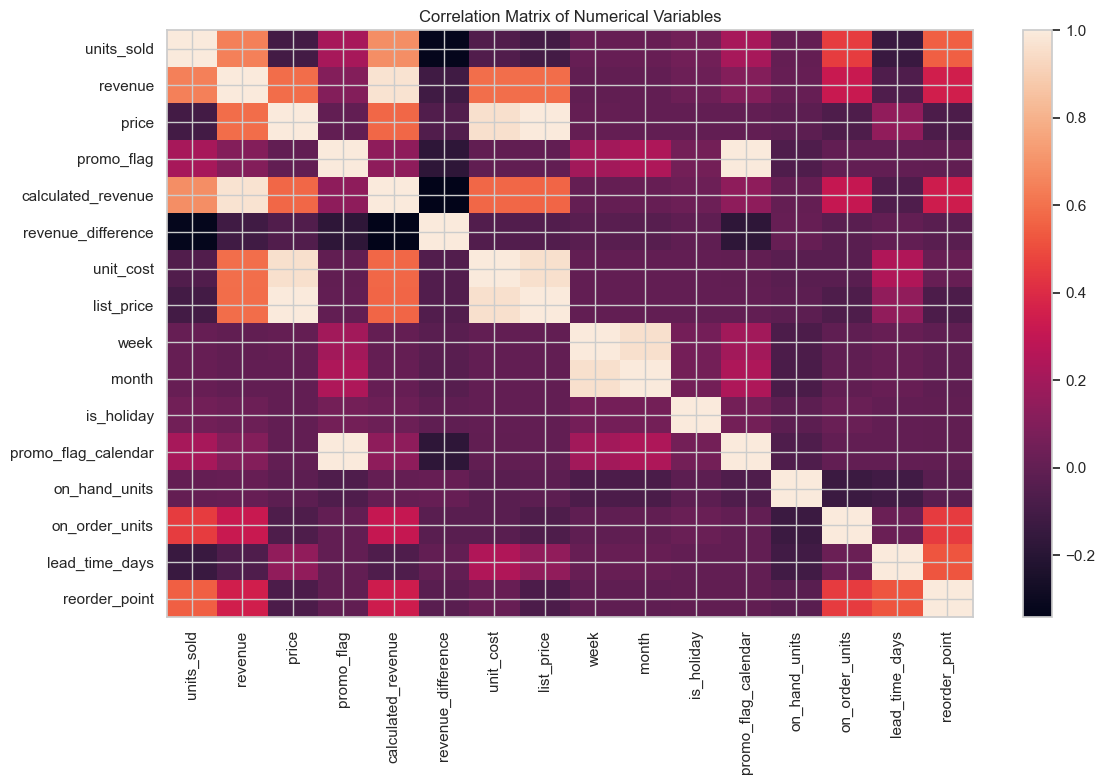

In [118]:
# Visualize the correlation matrix

plt.figure(figsize=(12, 8))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

## Key Business Insights

The exploratory analysis provides several important insights into the sales and demand patterns within the FORESIGHT dataset.

The analysis covered SKU performance, category-level sales, monthly trends, promotional activity, inventory-quality indicators, low-demand products, and relationships between numerical variables.

In [119]:
# Generate basic summary statistics for key business metrics

business_summary = {
    "Total Units Sold": df["units_sold"].sum(),
    "Total Revenue": df["revenue"].sum(),
    "Average Units Sold": df["units_sold"].mean(),
    "Average Revenue": df["revenue"].mean(),
    "Average Price": df["price"].mean(),
    "Number of SKUs": df["sku_id"].nunique(),
    "Number of Categories": df["category"].nunique()
}

business_summary

{'Total Units Sold': np.float64(1270795.0),
 'Total Revenue': np.float64(4922297084.34),
 'Average Units Sold': np.float64(60.82978316021253),
 'Average Revenue': np.float64(235449.0138878791),
 'Average Price': np.float64(4070.395134954058),
 'Number of SKUs': 40,
 'Number of Categories': 4}

In [120]:
# Identify the highest-performing category and SKU

top_category = (
    df.groupby("category")["units_sold"]
      .sum()
      .idxmax()
)

top_sku = (
    df.groupby("sku_id")["units_sold"]
      .sum()
      .idxmax()
)

print("Top Performing Category:", top_category)
print("Top Performing SKU:", top_sku)

Top Performing Category: Office
Top Performing SKU: SKU008


## Forecasting Implications

The findings from the exploratory analysis provide a foundation for the next stage of the FORESIGHT project: demand forecasting and predictive modeling.

The analysis indicates that future forecasting models should consider:

- Historical units sold
- Product/SKU-level demand
- Category-level demand patterns
- Monthly and seasonal trends
- Promotional activity
- Product pricing
- Data-quality indicators

These variables can help identify demand patterns and improve forecasting accuracy.

## EDA Conclusion

The Exploratory Data Analysis provided an overview of the FORESIGHT dataset and identified important patterns related to sales, demand, products, categories, promotions, and data quality.

The analysis of high-demand and low-demand SKUs can support inventory prioritization, while promotional and seasonal patterns can provide useful signals for future demand forecasting.

The insights generated in this notebook will be used as a foundation for developing forecasting and machine learning models in the subsequent stages of the project.

In [121]:
# Final dataset overview

print("FORESIGHT EDA Completed")
print("-" * 40)
print("Dataset Shape:", df.shape)
print("Total SKUs:", df["sku_id"].nunique())
print("Total Categories:", df["category"].nunique())
print("Total Units Sold:", df["units_sold"].sum())
print("Total Revenue:", df["revenue"].sum())
print("-" * 40)
print("Ready for the next stage: Demand Forecasting")

FORESIGHT EDA Completed
----------------------------------------
Dataset Shape: (20906, 26)
Total SKUs: 40
Total Categories: 4
Total Units Sold: 1270795.0
Total Revenue: 4922297084.34
----------------------------------------
Ready for the next stage: Demand Forecasting


## Additional EDA Visualizations

This section generates and saves the key exploratory visualizations used in the FORESIGHT project.

The generated charts are stored in the `visualizations/` directory for reporting and project documentation.

In [1]:
# ============================================================
# Additional EDA Visualization Setup
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Processed data
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "feature_engineered.csv"

# Visualization output folder
VISUALIZATION_DIR = PROJECT_ROOT / "visualizations"
VISUALIZATION_DIR.mkdir(parents=True, exist_ok=True)

# Load data
eda_df = pd.read_csv(DATA_PATH)

# Convert date
eda_df["date"] = pd.to_datetime(eda_df["date"], errors="coerce")

print("Dataset loaded successfully.")
print("Shape:", eda_df.shape)
print("Visualization folder:", VISUALIZATION_DIR)

Dataset loaded successfully.
Shape: (20906, 49)
Visualization folder: c:\Users\sharkon\Desktop\foresight-demand-inventory\visualizations


### 1. Category Analysis

This visualization shows total revenue generated by product category.

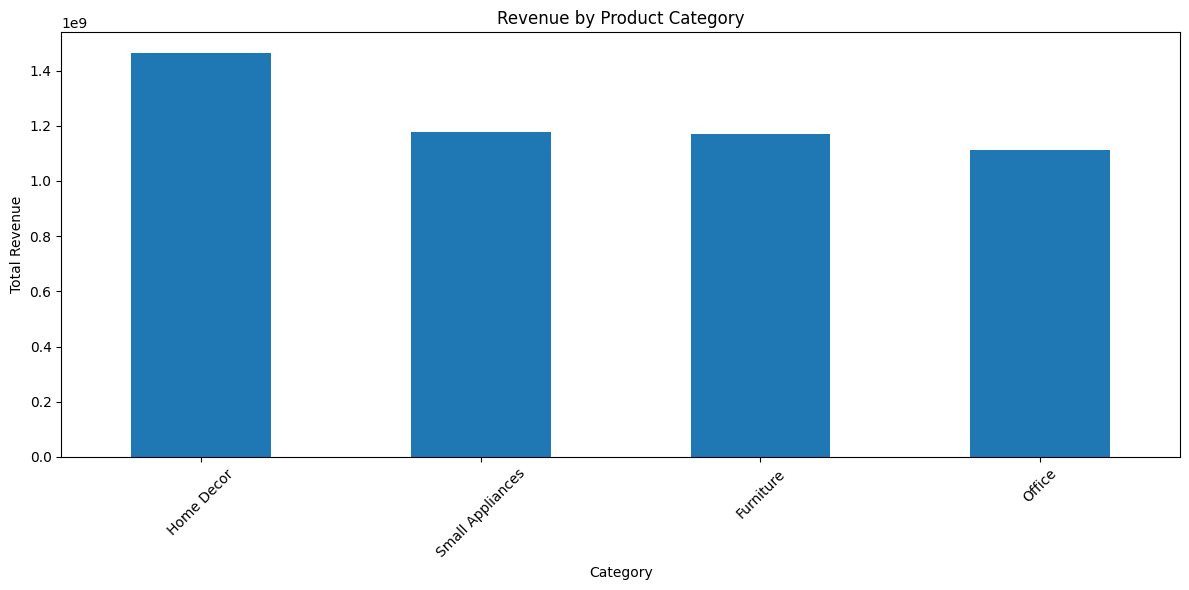

In [2]:
# ============================================================
# Category Analysis
# ============================================================

category_sales = (
    eda_df.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    VISUALIZATION_DIR / "category_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### 2. Dead Stock Analysis

This visualization identifies SKUs with inventory available but very low or zero demand.

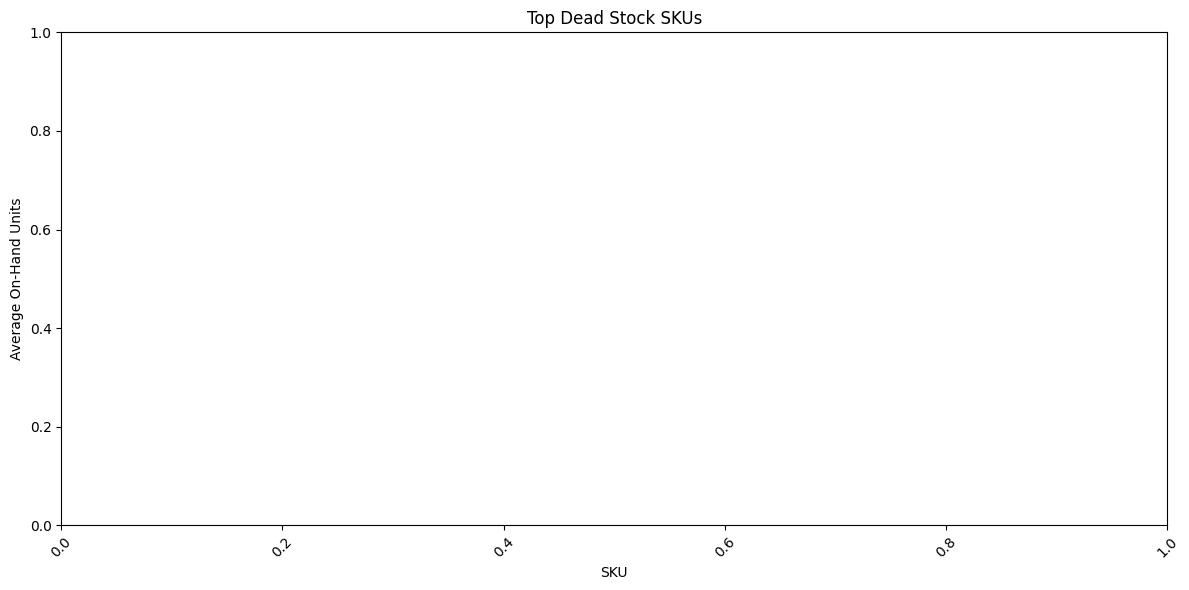

Dead stock SKUs: 0


In [3]:
# ============================================================
# Dead Stock Analysis
# ============================================================

dead_stock = (
    eda_df.groupby("sku_id")
    .agg(
        total_units_sold=("units_sold", "sum"),
        average_on_hand=("on_hand_units", "mean")
    )
    .reset_index()
)

dead_stock = dead_stock[
    (dead_stock["total_units_sold"] <= 0) &
    (dead_stock["average_on_hand"] > 0)
]

dead_stock = dead_stock.sort_values(
    "average_on_hand",
    ascending=False
).head(20)

plt.figure(figsize=(12, 6))

if not dead_stock.empty:
    plt.bar(
        dead_stock["sku_id"].astype(str),
        dead_stock["average_on_hand"]
    )

plt.title("Top Dead Stock SKUs")
plt.xlabel("SKU")
plt.ylabel("Average On-Hand Units")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    VISUALIZATION_DIR / "dead_stock.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Dead stock SKUs:", len(dead_stock))

### 3. Promotion Analysis

This visualization compares revenue generated during promotional and non-promotional periods.

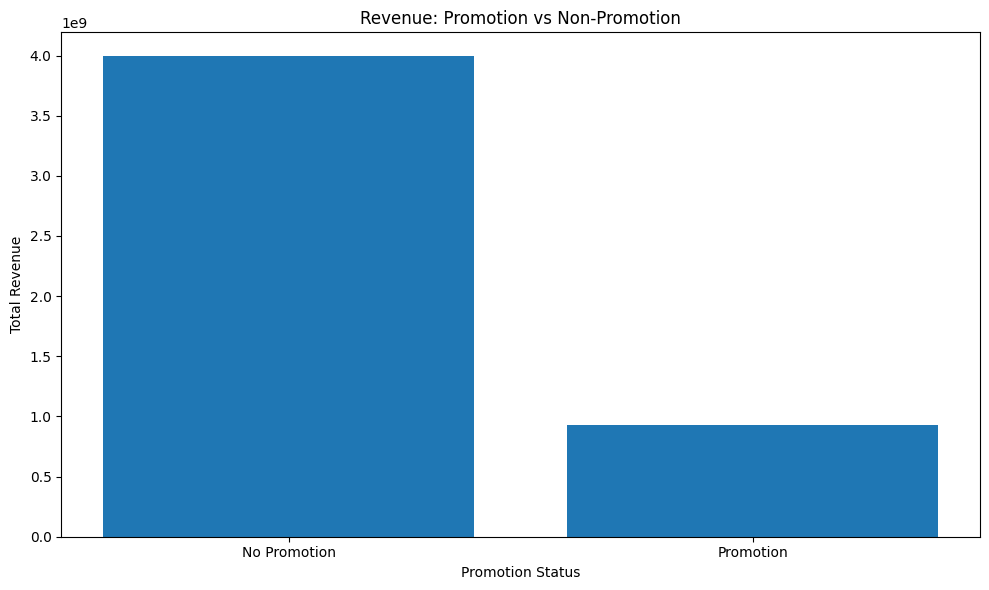

In [4]:
# ============================================================
# Promotion Analysis
# ============================================================

promotion_analysis = (
    eda_df.groupby("promo_flag")
    .agg(
        total_revenue=("revenue", "sum"),
        total_units_sold=("units_sold", "sum")
    )
    .reset_index()
)

promotion_analysis["Promotion"] = promotion_analysis[
    "promo_flag"
].map({
    0: "No Promotion",
    1: "Promotion"
})

plt.figure(figsize=(10, 6))

plt.bar(
    promotion_analysis["Promotion"],
    promotion_analysis["total_revenue"]
)

plt.title("Revenue: Promotion vs Non-Promotion")
plt.xlabel("Promotion Status")
plt.ylabel("Total Revenue")

plt.tight_layout()

plt.savefig(
    VISUALIZATION_DIR / "promotion_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### 4. Sales Trend

This visualization shows the overall daily revenue trend across the dataset period.

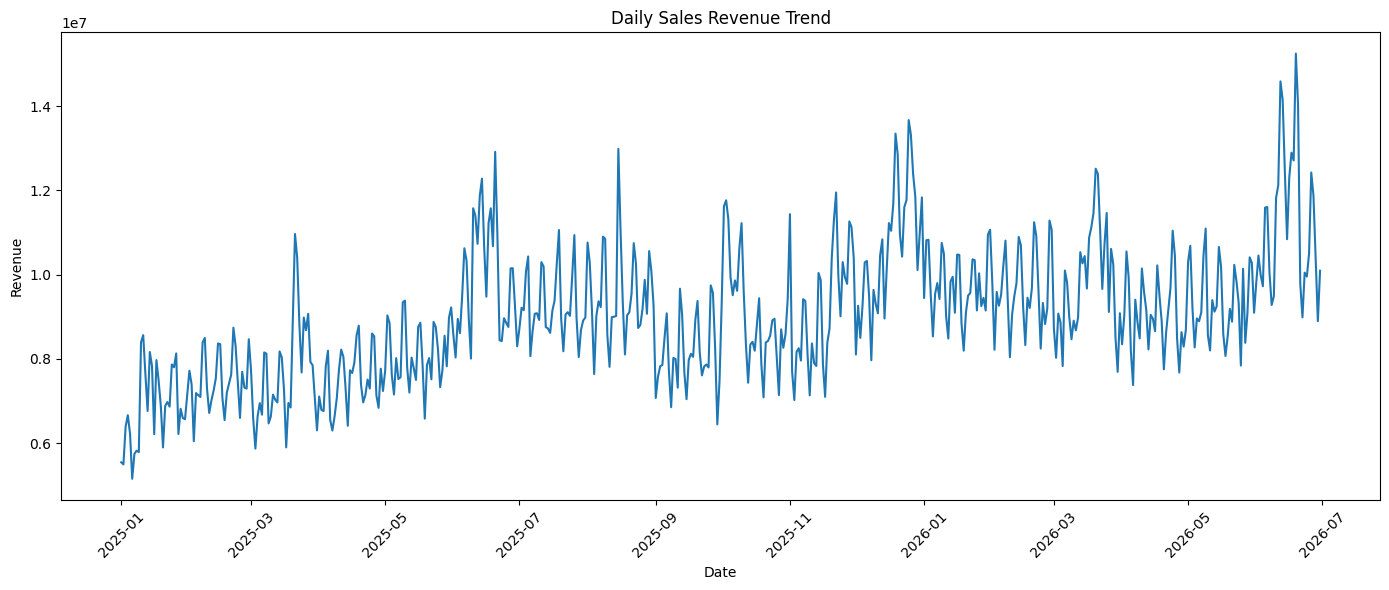

In [5]:
# ============================================================
# Sales Trend
# ============================================================

daily_sales = (
    eda_df.groupby("date")
    .agg(
        revenue=("revenue", "sum"),
        units_sold=("units_sold", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["revenue"]
)

plt.title("Daily Sales Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    VISUALIZATION_DIR / "sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### 5. Seasonal Demand Analysis

This visualization compares demand across different seasons.

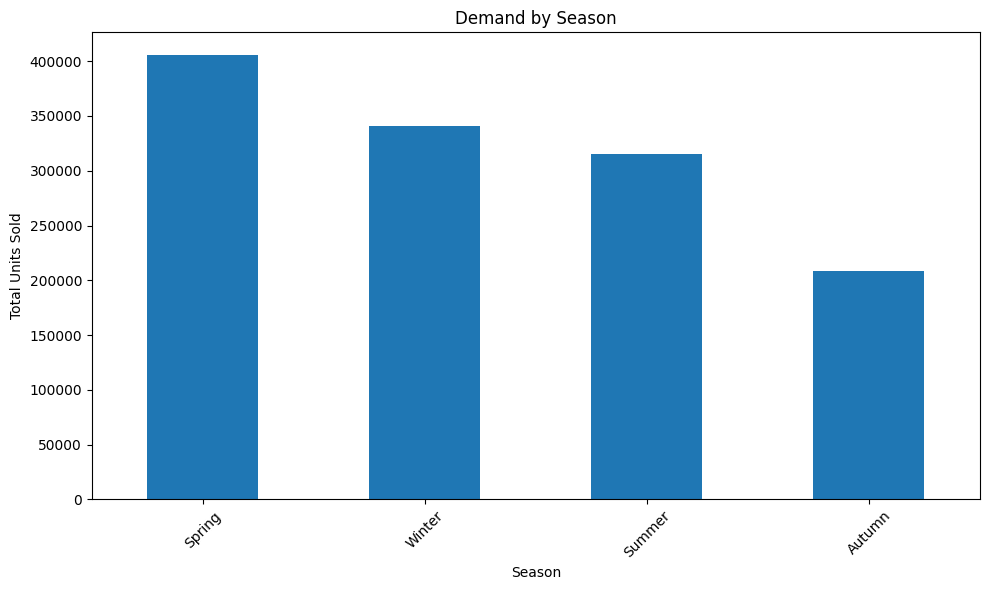

In [6]:
# ============================================================
# Seasonal Demand
# ============================================================

seasonal_demand = (
    eda_df.groupby("season")["units_sold"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

seasonal_demand.plot(kind="bar")

plt.title("Demand by Season")
plt.xlabel("Season")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    VISUALIZATION_DIR / "seasonal_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### 6. Top Moving SKUs

This visualization identifies the SKUs with the highest total unit sales.

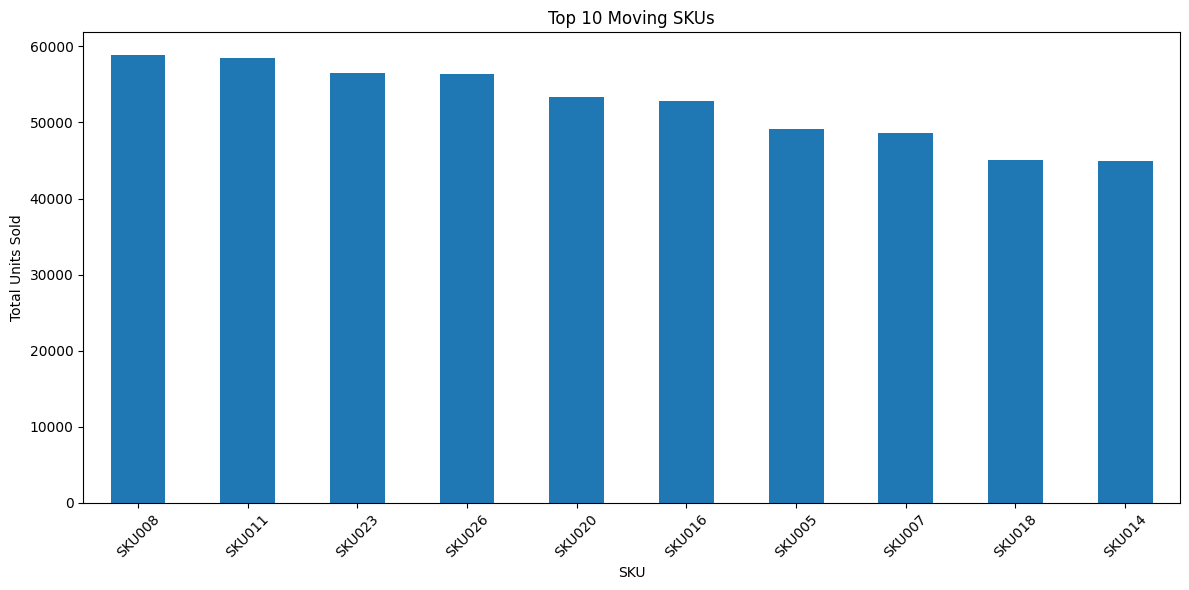

In [7]:
# ============================================================
# Top Movers
# ============================================================

top_movers = (
    eda_df.groupby("sku_id")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_movers.plot(kind="bar")

plt.title("Top 10 Moving SKUs")
plt.xlabel("SKU")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    VISUALIZATION_DIR / "top_movers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### 7. Weekly Demand Analysis

This visualization shows the overall demand pattern by week.

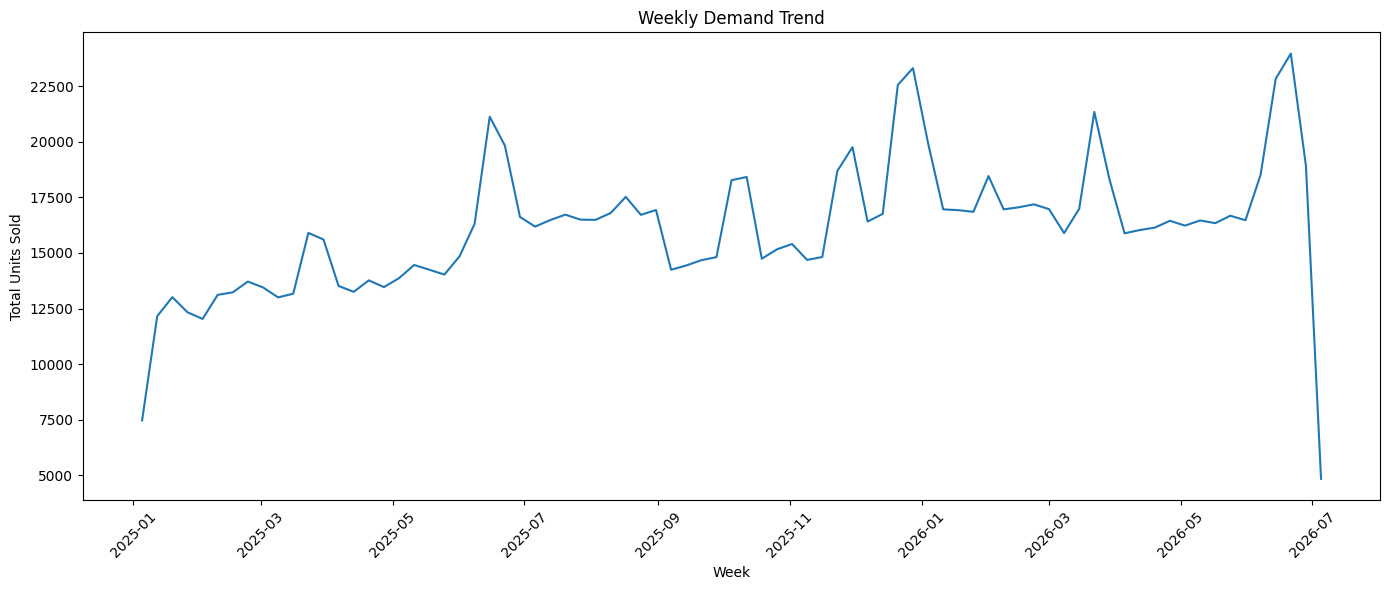

In [8]:
# ============================================================
# Weekly Demand
# ============================================================

weekly_demand = (
    eda_df
    .set_index("date")
    .resample("W")["units_sold"]
    .sum()
)

plt.figure(figsize=(14, 6))

plt.plot(
    weekly_demand.index,
    weekly_demand.values
)

plt.title("Weekly Demand Trend")
plt.xlabel("Week")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    VISUALIZATION_DIR / "weekly_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()